# 7. RANDOM FOREST


El siguiente notebook implementa el entrenamiento de un modelo Random Forest de ocurrencia de incendios usando puntos (presencia/ausencia) como unidad de entrenamiento. Se integran bandas e índices espectrales derivados de imagenes Landsat 8 y Sentinel 1, extrayendolas desde rasters en disco, seleccionados con reglas temporales definidas (L8: mes siguiente; S1: ventana post-incendio).

Flujo de trabajo:

 - Unifica y reproyecta capas vectoriales a un CRS de trabajo (EPSG:9377). 
 - Vincula cada punto con el raster “correspondiente” por reglas temporales.
 - Muestrea valores de bandas en la ubicación del punto (extracción puntual).
 - Construye tres datasets:
   - Dataset A (complete-case): solo filas sin faltantes en features.
   - Dataset B (imputado): rellena faltantes con mediana por clase (presencia vs ausencia).
   -   
 - Ejecuta validación cruzada sin fuga usando grupos por point_id (evita que el mismo punto entre en train y test por duplicación/re-muestreo).
 - Exporta resultados (GeoPackage + CSV + modelos + reporte de CV).

Se cuenta con 90% de entrenamiento y 10% de test para cada uno de los 10 folds que se realiza por Dataset, evitando que un mismo punto este en entrenamiento y test al tiempo y proporción igual de clases. Se cuenta con 500 arboles los cuales disminuyen la varianza

- 

<font color="red">

Se debe indicar el sesgo espacial y describir la relación entre la resolución de MODIS y VIIRS, donde el centroide del pixel representa el punto tomado y este se compara con el pixel de s1 y l8 que estan a mayor resolución que los satelites terra y aqua.

Problemas de autocorrelación espacial por cluster de puntos; la cercania de hasta 5 metros entre puntos de incendios (cada punto con una fecha diferente) podría estar relacionada con la orbita relativa y podría generar problemas de autocorrelación espacial por cluster de puntos?

¿Se debe correr índice de moran para determinar si los puntos son independientes entre si?

¿cual sería la resolución del resultado teniendo en cuenta que se entreno con el centroide de MODIS y resolución espacial de 30 m para las imagenes Landsat 8 y Sentinel 1?

</font>

## 7.1.1 Normalización variables ##

1. Construir dfA / dfB / dfC con valores crudos.
2. En validación cruzada:
   - calcular Min-Max solo con entrenamiento del fold;
   - aplicar a entrenamiento y prueba;
   - evaluar el modelo.
3. Entrenar modelo final:
   - calcular Min-Max con todo el dataset final del modelo;
   - normalizar todo el dataset;
   - entrenar modelo final.
4. Guardar:
   - modelo final .pkl;
   - parámetros Min-Max finales en Excel;
   - GeoTIFF normalizados por sensor y por modelo.
5. En notebook de probabilidad:
   - leer GeoTIFF L8 normalizado;
   - leer GeoTIFF S1 normalizado;
   - combinar bandas en el mismo orden de entrenamiento;
   - aplicar model.predict_proba();
   - exportar mapa de probabilidad.

Se importan librerias, se definen opciones de visualización, se importan métricas y validadores de scikit-lear para el RF; se definen las rutas donde se encuentra las ausencias, incendios, directorios donde estan los rasters a entrenar, excel con los metadatos de las imagenes Sentinel 1 y las salidas a obtener. 

Se definen las relgas temporales tanto para la selecciones de escenas Landsat 8 como Sentinel 1, que para ambos casos se define para el mes siguiente si el incendio ocurrio despues del día 14 del bimestre para el caso de Lansat 8, pero si el incendio ocurrio antes del 14 se tomaba la imagen del bimestre al que corresponde la fecha de incendio y para el caso de Sentinel 1 se escoge 1 mes despues del incendio.

Se realiza limpieza, manipulación de fechas y manejo de errores; primero se define el formato "dd/mm/aaaa", se determina la selección temporal y matching mensual. Se toma "acq_date" como fecha de incendio para comparar.

Se cargan dos fuentes de datos distintas (puntos donde hubo incendios y donde no), se estandarizan y se unen a un solo conjunto de datos. Se validan las fechas en el formato definido y se reproyectan ambos a EPSG:9377, se concatena y se crea un point_id único. Si hay errores en las fechas el codigo no continua.

Se estandariza y limpia el formato de fechas para el subconjunto de incendios, en caso de encontrar inconsistencias en las fehcas asigna NaT. De acuerdo a lo anterior se le asignan fechas a los puntos de ausencia de incendio, asignandole a cada ausencia una fecha muestreada aleatoriamente desde las fechas reales de incendios con el objetivo de aplicar las mismas reglas temporales de selección de images para ausencias y evitando que el modelo aprenda que presencia = tiene fecha y ausencia =NaT

Se localizan los archivos de imagen dentro del almacenamiento local y se crea un índice organizado para que el modelo identifique qué archivo abrir de acuerdo a la fecha que se necesite consultar. Tanto para las imagenes Landsat 8 como para las Sentinel 1 se asume que el nombre del archivo contiene la información necesaria. 

Se realiza la selección temporal tanto para imagenes L8 como para S1, a partir de las ventanas de tiempo definidas para ello (imagenes unicamente para un mes despues del incendio), mediante la función "sample_raster_at_points" donde se extraen los valores de los pixeles para cada una de las imagenes en el punto determinado y se convierten los valores "nodata" en "NaN" para no arruinar los cálculos estadísticos posteriores. 

Se construye un geodataframe donde cada punto corresponde a una fila y las columnas corresponden a las variables tanto de las imagenes Landsat 8 y Sentinel 1. Se realiza normalización de fechas y limpieza de metadatos; se crean las variables finales del modelo y las inicializa en NaN; permite trazabilidad del proceso. Se calcula el mes objetivo por punto y esta información se guarda en columnas, se procesa en grupos (año, mes).

Se concatenan dos listas de nombres de columnas, definiendose las columnas que se usaran en el modelo y se elimina cualquier fila que tenga al menos un valor nulo en cualquiera de las columnas. Se realiza una prueba de validación para confirmar que la función esta funcionando correctamente.

Se evalua si las variables tienen suficientes datos; se evalua cuantos vaores faltantes (NaN) tiene cada feature; se realiza un diagnostico global de clases y ver si el dataset esta desbalanceado antes de construir el Dataset A y el Datasdet B; diagnostico de cobertura de Landsat 8 y Sentinel 1.

Se crea la función que construye el Dataset A, donde se conservan los puntos con todas las varibles que existen para ese punto; balanceo exacto 1:1 (incendios y ausencia) preferiblemente en el mismo mes o el mes vecino. allow_replacemente=true permite reemplazar las ausencias, para mantener el balance entre incendios y ausencias para un mismo mes; sin embargo se asignaron las fechas de ausencias semejantes a las de incendio en los puntos aleatorios cercanas al mes de incendio. En caso de que no existan suficientes ausencias el mes siguiente, se reducen las presencias.

Se realiza imputación de NaN por clase a partir de la mediana, donde se eliminan valores faltantes en las variables predictoras, reemplazandose por la mediana, para poder entrenar el Random Forest sin descartar filas (a diferencia del Dataset A. Se contruye el Dataset B donde no se cuenta con ninguna variable con valores NaN y balanceado 1:1 por mes)

Se realiza validación cruzada para garantizar que tan bien generaliza el modelo a datos nuevos, entrenandose 10 veces, evitandose fuga al impedir que el modelo emplee puntos de test como entrenamiento, usando "StratifiedGroupKFold", donde cada reporte produce una evaluación independiente. Se genera reporte en texto de la implementación del modelo en los dos dataset junto con su estadistica descriptiva.

Se genera un reporte en geopackage con la trazabilidad de la información seleccionada para el desarrollo del modelo, se imprime el reporte en texto final y se entregan los modelos tanto del Dataset A como del Dataset B. Se normalizan las fechas; se nornaliza texto en columnas.


In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
from pathlib import Path
import logging
import sys

PROJECT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from src.pipeline_rf_Copy1 import run_pipeline, run_pipeline_model_c
from src.config_rf_pipeline_Copy1 import load_config

cfg = load_config(PROJECT / "configs" / "RandomForest_260507_Copy1.json")

log_path = PROJECT / "logs" / "rf_pipeline_260507-Copy1.log"
log_path.parent.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename=str(log_path),
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    force=True
)

logger = logging.getLogger("RandomForest_260507-Copy1")
logger.info("Inicio pipeline RF con normalización Min-Max por fold-Copy1")

In [6]:
# =========================================================
# MODELOS A Y B
# =========================================================

res = run_pipeline(cfg, logger)

print("========== MODELOS A Y B ==========")
print("OUT_DIR:", res["out_dir"])
print("Raw features:", res["raw_features"])
print("Features normalizadas:", res["features"])
print("Excel Min-Max:", res["normalization_excel"])

print("\nDataset A normalizado:", res["dfA"].shape)
print("Dataset B normalizado:", res["dfB"].shape)

display(res["coverage"])

print("Parámetros finales Modelo A")
display(res["params_A_final"])

print("Parámetros finales Modelo B")
display(res["params_B_final"])

print("Parámetros por fold Modelo A")
display(res["params_A_folds"].head())

print("Parámetros por fold Modelo B")
display(res["params_B_folds"].head())

display(res["foldsA"].head())
display(res["foldsB"].head())
display(res["dfA"].head())
display(res["dfB"].head())

C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\src\points_loader.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  g = pd.concat([g_fire, g_abs], ignore_index=True)


=== DEBUG PRE-CV ===
g_points: (1922, 51)
g_master: (1922, 75)
FEATURES: ['SR_B5_norm', 'SR_B6_norm', 'SR_B7_norm', 'NDVI_norm', 'EVI_norm', 'NBR_norm', 'NDWI_norm', 'VV_norm', 'VH_norm', 'angle_norm', 'VVVH_ratio_norm', 'VV_Difference_norm', 'VH_Difference_norm', 'VHVV_Difference_norm']

Conteo label en g_master:
label
1    961
0    961
Name: count, dtype: int64

L8 found:
l8_found
True     1055
False     867
Name: count, dtype: int64

S1 found:
s1_found
False    1292
True      630
Name: count, dtype: int64

NaN por feature cruda en g_master:
SR_B5              1222
SR_B6              1222
SR_B7              1222
NDVI               1222
EVI                1222
NBR                1222
NDWI               1222
VV                 1370
VH                 1370
angle              1366
VVVH_ratio         1370
VV_Difference      1321
VH_Difference      1321
VHVV_Difference    1321
dtype: int64

Complete cases en RAW_FEATURES:
(341, 75)
label
0    171
1    170
Name: count, dtype: int64

dfA sha

,feature,missing_n,missing_pct
7,VV,1370,71.279917
8,VH,1370,71.279917
10,VVVH_ratio,1370,71.279917
9,angle,1366,71.071800
11,VV_Difference,1321,68.730489
12,VH_Difference,1321,68.730489
13,VHVV_Difference,1321,68.730489
0,SR_B5,1222,63.579605
1,SR_B6,1222,63.579605
2,SR_B7,1222,63.579605


Parámetros finales Modelo A


,modelo,fold,variable_original,variable_normalizada,min_dataset,max_dataset,denominador,n_validos,n_na,estado,observacion
0,A_final,None,SR_B5,SR_B5_norm,0.051542,0.494952,0.443410,340,0,ok,Parámetros Min-Max calculados correctamente.
1,A_final,None,SR_B6,SR_B6_norm,0.046345,0.439568,0.393223,340,0,ok,Parámetros Min-Max calculados correctamente.
2,A_final,None,SR_B7,SR_B7_norm,0.023355,0.472347,0.448992,340,0,ok,Parámetros Min-Max calculados correctamente.
3,A_final,None,NDVI,NDVI_norm,0.135164,0.864327,0.729163,340,0,ok,Parámetros Min-Max calculados correctamente.
4,A_final,None,EVI,EVI_norm,0.029208,0.666025,0.636817,340,0,ok,Parámetros Min-Max calculados correctamente.
5,A_final,None,NBR,NBR_norm,-0.421298,0.431605,0.852903,340,0,ok,Parámetros Min-Max calculados correctamente.
6,A_final,None,NDWI,NDWI_norm,-0.826910,-0.210520,0.616390,340,0,ok,Parámetros Min-Max calculados correctamente.
7,A_final,None,VV,VV_norm,-13.367093,-0.006370,13.360723,340,0,ok,Parámetros Min-Max calculados correctamente.
8,A_final,None,VH,VH_norm,-20.398693,-4.961008,15.437685,340,0,ok,Parámetros Min-Max calculados correctamente.
9,A_final,None,angle,angle_norm,31.103386,45.999645,14.896259,340,0,ok,Parámetros Min-Max calculados correctamente.


...

,modelo,fold,variable_original,variable_normalizada,min_dataset,max_dataset,denominador,n_validos,n_na,estado,observacion
0,B,1,SR_B5,SR_B5_norm,0.051542,0.495530,0.443988,1732,0,ok,Parámetros Min-Max calculados correctamente.
1,B,1,SR_B6,SR_B6_norm,0.039704,0.475304,0.435600,1732,0,ok,Parámetros Min-Max calculados correctamente.
2,B,1,SR_B7,SR_B7_norm,0.020165,0.730215,0.710050,1732,0,ok,Parámetros Min-Max calculados correctamente.
3,B,1,NDVI,NDVI_norm,0.135164,0.864327,0.729163,1732,0,ok,Parámetros Min-Max calculados correctamente.
4,B,1,EVI,EVI_norm,0.029208,0.698621,0.669412,1732,0,ok,Parámetros Min-Max calculados correctamente.


,modelo,fold,cv,n_train,n_test,balanced_accuracy,precision_pos,recall_pos,f1_pos,precision_neg,recall_neg,f1_neg,tn,fp,fn,tp
0,A,1,StratifiedGroupKFold,306,34,0.854386,0.812500,0.866667,0.838710,0.888889,0.842105,0.864865,16,3,2,13
1,A,2,StratifiedGroupKFold,307,33,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,16,0,0,17
2,A,3,StratifiedGroupKFold,310,30,0.897321,0.882353,0.937500,0.909091,0.923077,0.857143,0.888889,12,2,1,15
3,A,4,StratifiedGroupKFold,308,32,0.841176,0.833333,0.882353,0.857143,0.857143,0.800000,0.827586,12,3,2,15
4,A,5,StratifiedGroupKFold,306,34,0.921053,1.000000,0.842105,0.914286,0.833333,1.000000,0.909091,15,0,3,16


,modelo,fold,cv,n_train,n_test,balanced_accuracy,precision_pos,recall_pos,f1_pos,precision_neg,recall_neg,f1_neg,tn,fp,fn,tp
0,B,1,StratifiedGroupKFold,1732,190,0.968528,0.958333,0.978723,0.968421,0.978723,0.958333,0.968421,92,4,2,92
1,B,2,StratifiedGroupKFold,1726,196,0.974239,0.978495,0.968085,0.973262,0.970874,0.980392,0.975610,100,2,3,91
2,B,3,StratifiedGroupKFold,1730,192,0.968750,0.959184,0.979167,0.969072,0.978723,0.958333,0.968421,92,4,2,94
3,B,4,StratifiedGroupKFold,1732,190,0.984536,1.000000,0.969072,0.984293,0.968750,1.000000,0.984127,93,0,3,94
4,B,5,StratifiedGroupKFold,1725,197,0.964227,0.978723,0.948454,0.963351,0.951456,0.980000,0.965517,98,2,5,92


,idx_firms,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,...,EVI_norm,NBR_norm,NDWI_norm,VV_norm,VH_norm,angle_norm,VVVH_ratio_norm,VV_Difference_norm,VH_Difference_norm,VHVV_Difference_norm
0,869.0,5.47858,-73.51540,298.48,0.38,0.36,2017-04-18,0622,N,VIIRS,...,0.830933,0.955272,0.173985,0.563349,0.535449,0.081165,0.328649,0.611186,0.545807,0.413302
1,893.0,5.48021,-73.52576,296.33,0.38,0.36,2017-04-18,0622,N,VIIRS,...,0.443096,0.702653,0.313899,0.283538,0.375095,0.076140,0.146126,0.582783,0.430620,0.363129
2,898.0,5.47691,-73.52627,304.91,0.38,0.36,2017-04-18,0622,N,VIIRS,...,0.208024,0.583380,0.554645,0.303219,0.360454,0.075571,0.216792,0.527510,0.672339,0.593039
3,947.0,5.47059,-73.54893,309.29,0.38,0.36,2017-04-18,0622,N,VIIRS,...,0.109553,0.351594,0.913728,0.350141,0.363950,0.063388,0.299592,0.437020,0.460955,0.542589
4,1021.0,5.46507,-73.55687,298.37,0.38,0.36,2017-04-18,0622,N,VIIRS,...,0.171768,0.531179,0.672425,0.648273,0.708140,0.058140,0.107348,0.559011,0.779570,0.634257


,idx_firms,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,...,EVI_norm,NBR_norm,NDWI_norm,VV_norm,VH_norm,angle_norm,VVVH_ratio_norm,VV_Difference_norm,VH_Difference_norm,VHVV_Difference_norm
0,7.0,5.78100,-73.56840,322.50,1.20,1.10,2014-09-29,1835,Aqua,MODIS,...,0.421231,0.622643,0.230578,0.375541,0.334055,0.075683,0.337999,0.52633,0.501903,0.485218
1,8.0,5.77960,-73.57840,318.10,1.20,1.10,2014-09-29,1835,Aqua,MODIS,...,0.477836,0.822497,0.141608,0.375541,0.334055,0.075683,0.337999,0.52633,0.501903,0.485218
2,16.0,5.47922,-73.51354,295.42,0.39,0.44,2014-02-04,0645,N,VIIRS,...,0.377019,0.797986,0.250180,0.375541,0.334055,0.075683,0.337999,0.52633,0.501903,0.485218
3,17.0,5.47701,-73.52529,300.45,0.39,0.44,2014-02-04,0645,N,VIIRS,...,0.185313,0.605583,0.376401,0.375541,0.334055,0.075683,0.337999,0.52633,0.501903,0.485218
4,21.0,5.61784,-73.31963,340.57,0.42,0.38,2014-02-02,1826,N,VIIRS,...,0.500515,0.625544,0.356442,0.375541,0.334055,0.075683,0.337999,0.52633,0.501903,0.485218


In [ ]:
# =========================================================
# MODELO C
# =========================================================

resC = run_pipeline_model_c(cfg, logger)

print("========== MODELO C ==========")
print("OUT_DIR:", resC["out_dir"])
print("Raw features:", resC["raw_features"])
print("Features normalizadas Modelo C:", resC["featuresC"])
print("Excel Min-Max C:", resC["normalization_excel_C"])

print("\nDataset C normalizado:", resC["dfC"].shape)

display(resC["coverageC"])

print("Parámetros finales Modelo C")
display(resC["params_C_final"])

print("Parámetros por fold Modelo C")
display(resC["params_C_folds"].head())

display(resC["foldsC"].head())
display(resC["dfC"].head())

C:\Users\Equipo\Tesis\SemestreIV\Objetivo1\Objetivo1_26_02_20\src\points_loader.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  g = pd.concat([g_fire, g_abs], ignore_index=True)


=== DEBUG PRE-CV MODELO C ===
g_points: (1922, 51)
g_master_c: (1922, 80)
FEATURES_C: ['SR_B5_norm', 'SR_B6_norm', 'SR_B7_norm', 'NDVI_norm', 'EVI_norm', 'NBR_norm', 'NDWI_norm', 'VV_norm', 'VH_norm', 'angle_norm', 'VVVH_ratio_norm', 'VV_Difference_norm', 'VH_Difference_norm', 'VHVV_Difference_norm']

Conteo label en g_master_c:
label
1    961
0    961
Name: count, dtype: int64

L8 found:
l8_found
True     1055
False     867
Name: count, dtype: int64

S1 general found:
s1_general_found
False    1292
True      630
Name: count, dtype: int64

S1 difference found:
s1_difference_found
False    1292
True      630
Name: count, dtype: int64

NaN por feature cruda en g_master_c:
SR_B5              1222
SR_B6              1222
SR_B7              1222
NDVI               1222
EVI                1222
NBR                1222
NDWI               1222
VV                 1370
VH                 1370
angle              1366
VVVH_ratio         1370
VV_Difference      1357
VH_Difference      1357
VHVV_Diff

In [ ]:
print(res["features"])

for col in res["features"]:
    print(
        col,
        "A min:", res["dfA"][col].min(skipna=True),
        "A max:", res["dfA"][col].max(skipna=True)
    )

In [ ]:
for col in res["features"]:
    print(
        col,
        "B min:", res["dfB"][col].min(skipna=True),
        "B max:", res["dfB"][col].max(skipna=True)
    )

In [ ]:
for col in resC["featuresC"]:
    print(
        col,
        "C min:", resC["dfC"][col].min(skipna=True),
        "C max:", resC["dfC"][col].max(skipna=True)
    )

## 7.2 Aplicación modelo A en imagenes de agosto de 2019 para detectar incendios de julio de 2019 ##



Se busca ejecutar la inferencia espacial con Random Forest usando Landsat 8 + Sentinel -1. Objetivos de este notebook:
- cargar `config_ModeloA.json`
- ejecutar el pipeline
- revisar salidas GeoTIFF
- visualizar resultados
- correr validación solo si está activada

Se ejecuta el pipeline, donde:

- carga de modelo
- lectura de L8 y S1
- construcción de features
- inferencia RF
- exportación de `prob.tif` y `bin.tif`
- validación opcional

Ajustar primero el archivo .json con las rutas reales en Windows. Se verifica en donde se encuentra la ruta del archivo. Se alinean ambos raster, ya que se encuentran con extensiones y crs diferentes, tomando como base el GeoTIFF de Landsat 8

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from pathlib import Path
import sys
import json
import joblib

# Root del proyecto: .../tesis_rf o carpeta equivalente
PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/Equipo/Tesis/SemestreIV/Objetivo1')

In [9]:
from src.config_ModeloA import load_config
from src.pipeline_ModeloA import run_pipeline
from src.preprocess_ModeloA import align_raster_to_reference, compare_raster_grids
from src.logging_utils_ModeloA import setup_logger

CONFIG_PATH = PROJECT_ROOT / "Objetivo1_26_02_20" / "configs" / "config_ModeloA.json"

cfg = load_config(CONFIG_PATH)

logger = setup_logger(
    name="pipeline_RF_A_260507",
    log_file=cfg["logging"]["log_file"]
)

cfg

{'paths': {'model': 'C:/Users/Equipo/Tesis/SemestreIV/Objetivo1/Objetivo1_26_02_20/outputs/outputs_rf_pipeline_260507/modelo_RF_A_260507.pkl',
  'l8': 'D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/L8_normalizado/L8_2019_jul_ago_normalizado.tif',
  's1': 'D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/S1_normalizado/S1_2019-08-27_4_prepost_indices_normalizado.tif',
  's1_aligned': 'D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/S1_normalizado/S1_2019-08-27_4_prepost_indices_normalizado_aligned_to_L8_2019_jul_ago_normalizado.tif',
  'fire_points': None},
 'preprocess': {'s1_resampling': 'bilinear'},
 'layers': {'fire_layer': None},
 'features': ['SR_B5_norm',
  'SR_B6_norm',
  'SR_B7_norm',
  'NDVI_norm',
  'EVI_norm',
  'NBR_norm',
  'NDWI_norm',
  'VV_norm',
  'VH_norm',
  'angle_norm',
  'VVVH_ratio_norm',
  'VV_Difference_norm',
  'VH_Difference_norm',
  'VHVV_Difference_norm'],
 'l8_band_map': {'SR_B5_norm': 'SR_B5_norm',
  'SR_B6_norm': 'SR_B6_nor

In [11]:
# Revisar bandas disponibles en Landsat 8 y Sentinel-1

import rasterio

with rasterio.open(cfg["paths"]["l8"]) as src:
    print("Landsat 8")
    print("Número de bandas:", src.count)
    print("Descriptions:", src.descriptions)

with rasterio.open(cfg["paths"]["s1"]) as src:
    print("\nSentinel-1")
    print("Número de bandas:", src.count)
    print("Descriptions:", src.descriptions)

Landsat 8
Número de bandas: 7
Descriptions: ('SR_B5_norm', 'SR_B6_norm', 'SR_B7_norm', 'NDVI_norm', 'EVI_norm', 'NBR_norm', 'NDWI_norm')

Sentinel-1
Número de bandas: 7
Descriptions: ('VV_norm', 'VH_norm', 'angle_norm', 'VVVH_ratio_norm', 'VV_Difference_norm', 'VH_Difference_norm', 'VHVV_Difference_norm')


In [13]:
# Comparar grillas antes de alinear Sentinel-1

align_before = compare_raster_grids(
    reference_path=cfg["paths"]["l8"],
    other_path=cfg["paths"]["s1"]
)

print(json.dumps(align_before, indent=2, ensure_ascii=False))

{
  "reference_path": "D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/L8_normalizado/L8_2019_jul_ago_normalizado.tif",
  "other_path": "D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/S1_normalizado/S1_2019-08-27_4_prepost_indices_normalizado.tif",
  "same_width": true,
  "same_height": false,
  "same_crs": true,
  "same_transform": false,
  "reference_shape": [
    1820,
    2671
  ],
  "other_shape": [
    1821,
    2671
  ],
  "reference_crs": "EPSG:4326",
  "other_crs": "EPSG:4326",
  "reference_transform": [
    0.00026949458523585647,
    0.0,
    -73.68547898977312,
    0.0,
    -0.00026949458523585647,
    5.906243330029031,
    0.0,
    0.0,
    1.0
  ],
  "other_transform": [
    0.0002694945852358564,
    0.0,
    -73.68533349709925,
    0.0,
    -0.0002694945852358564,
    5.90637725659208,
    0.0,
    0.0,
    1.0
  ]
}


In [15]:
# Alinear Sentinel-1 a la grilla exacta de Landsat 8

s1_aligned_path = align_raster_to_reference(
    reference_path=cfg["paths"]["l8"],
    source_path=cfg["paths"]["s1"],
    output_path=cfg["paths"]["s1_aligned"],
    band_map=cfg["s1_band_map"],
    band_order=cfg["s1_band_order"],
    resampling_method=cfg["preprocess"]["s1_resampling"]
)

print("S1 alineado creado en:", s1_aligned_path)

S1 alineado creado en: D:\Maestria_Geomatica\Semestre_IV\Tesis_Python\Datos\TIFF\S1_normalizado\S1_2019-08-27_4_prepost_indices_normalizado_aligned_to_L8_2019_jul_ago_normalizado.tif


In [16]:
# Comparar grillas después de alinear Sentinel-1

align_after = compare_raster_grids(
    reference_path=cfg["paths"]["l8"],
    other_path=cfg["paths"]["s1_aligned"]
)

print(json.dumps(align_after, indent=2, ensure_ascii=False))

{
  "reference_path": "D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/L8_normalizado/L8_2019_jul_ago_normalizado.tif",
  "other_path": "D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/S1_normalizado/S1_2019-08-27_4_prepost_indices_normalizado_aligned_to_L8_2019_jul_ago_normalizado.tif",
  "same_width": true,
  "same_height": true,
  "same_crs": true,
  "same_transform": true,
  "reference_shape": [
    1820,
    2671
  ],
  "other_shape": [
    1820,
    2671
  ],
  "reference_crs": "EPSG:4326",
  "other_crs": "EPSG:4326",
  "reference_transform": [
    0.00026949458523585647,
    0.0,
    -73.68547898977312,
    0.0,
    -0.00026949458523585647,
    5.906243330029031,
    0.0,
    0.0,
    1.0
  ],
  "other_transform": [
    0.00026949458523585647,
    0.0,
    -73.68547898977312,
    0.0,
    -0.00026949458523585647,
    5.906243330029031,
    0.0,
    0.0,
    1.0
  ]
}


In [17]:
# Usar el Sentinel-1 alineado para la inferencia

cfg["paths"]["s1"] = cfg["paths"]["s1_aligned"]

In [21]:
# Verificar que las variables del modelo coincidan con cfg["features"]

model = joblib.load(cfg["paths"]["model"])

if hasattr(model, "feature_names_in_"):
    model_features = list(model.feature_names_in_)
    cfg_features = list(cfg["features"])

    print("Variables esperadas por el modelo:")
    print(model_features)

    print("\nVariables configuradas:")
    print(cfg_features)

    if model_features != cfg_features:
        raise ValueError(
            "ERROR: cfg['features'] no coincide exactamente con model.feature_names_in_.\n"
            f"Modelo espera: {model_features}\n"
            f"Config tiene: {cfg_features}"
        )
else:
    print(
        "Advertencia: el modelo no contiene feature_names_in_. "
        "Se asumirá que cfg['features'] está en el orden correcto."
    )

Advertencia: el modelo no contiene feature_names_in_. Se asumirá que cfg['features'] está en el orden correcto.


In [23]:
# Ejecutar inferencia espacial

results = run_pipeline(cfg, logger)

results

2026-05-14 09:55:03 | INFO | pipeline_RF_A_260507 | Iniciando pipeline de inferencia RF
2026-05-14 09:55:03 | INFO | pipeline_RF_A_260507 | Modelo: C:/Users/Equipo/Tesis/SemestreIV/Objetivo1/Objetivo1_26_02_20/outputs/outputs_rf_pipeline_260507/modelo_RF_A_260507.pkl
2026-05-14 09:55:03 | INFO | pipeline_RF_A_260507 | L8: D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/L8_normalizado/L8_2019_jul_ago_normalizado.tif
2026-05-14 09:55:03 | INFO | pipeline_RF_A_260507 | S1: D:/Maestria_Geomatica/Semestre_IV/Tesis_Python/Datos/TIFF/S1_normalizado/S1_2019-08-27_4_prepost_indices_normalizado_aligned_to_L8_2019_jul_ago_normalizado.tif
2026-05-14 09:55:03 | INFO | pipeline_RF_A_260507 | Alineación raster: {'same_width': True, 'same_height': True, 'same_crs': True, 'same_transform': True, 'l8_shape': (1820, 2671), 's1_shape': (1820, 2671), 'l8_crs': 'EPSG:4326', 's1_crs': 'EPSG:4326'}
2026-05-14 09:55:06 | INFO | pipeline_RF_A_260507 | Resumen inferencia: {'pixels_totales': 4861220, 'p

{'mode': 'in_memory',
 'summary': {'pixels_totales': 4861220,
  'pixels_validos': 3678097,
  'pct_validos': 75.66201488515229,
  'n_features': 14,
  'features': ['SR_B5_norm',
   'SR_B6_norm',
   'SR_B7_norm',
   'NDVI_norm',
   'EVI_norm',
   'NBR_norm',
   'NDWI_norm',
   'VV_norm',
   'VH_norm',
   'angle_norm',
   'VVVH_ratio_norm',
   'VV_Difference_norm',
   'VH_Difference_norm',
   'VHVV_Difference_norm']},
 'outputs': {'prob': 'outputs/rasters/rf_probabilidad_quemado_RF_A_260507_2019_jul_agos.tif',
  'bin': 'outputs/rasters/rf_quemado_binario_RF_A_260507_2019_jul_agos.tif'},
 'validation': None}

## Probabilidad quemado rf_probabilidad_quemado_RF_A_260507_2019_jul_agos.tif ##

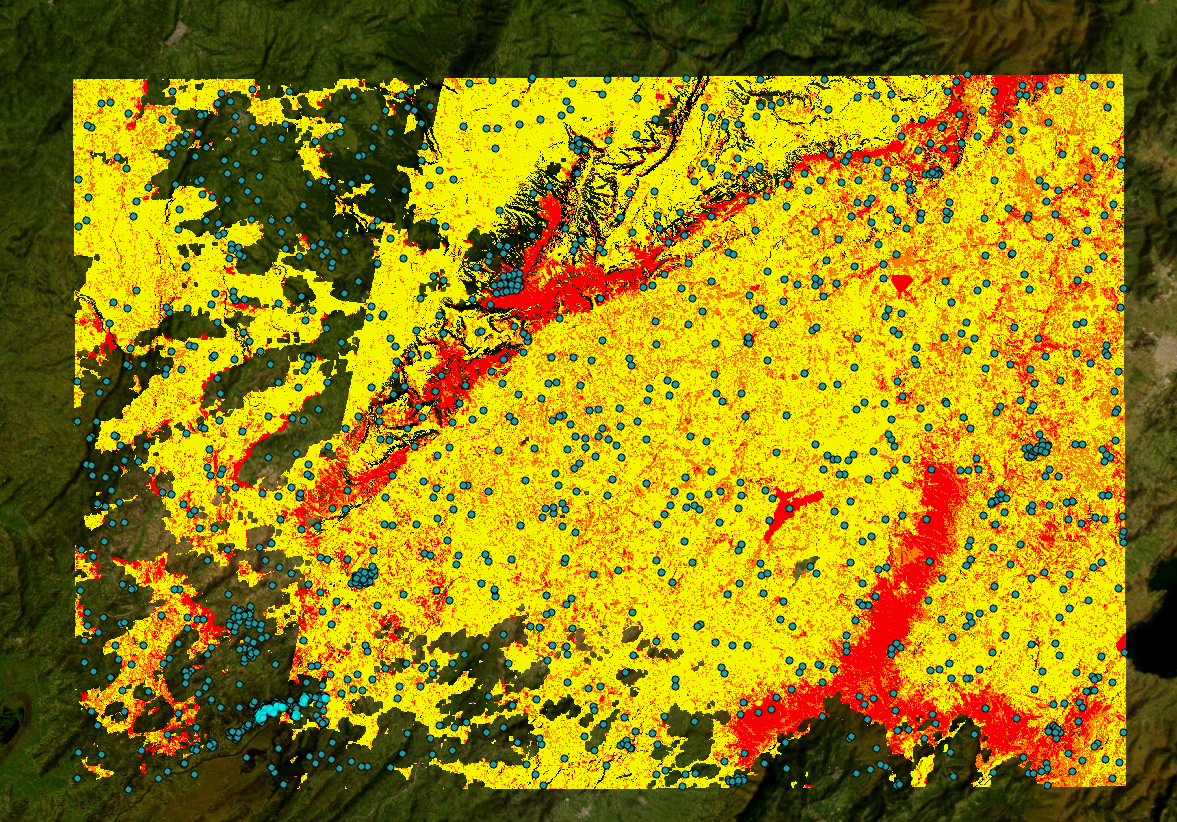